In [1]:
# Dada una canasta que contiene tropical fruit y yogurt, ¿qué producto es más probable que también aparezca en la misma compra?

from collections import Counter
from itertools import combinations
from pathlib import Path
import gzip

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

activity_dir = Path("..")
data_path = activity_dir / "data" / "groceries_baskets.csv.gz"
submission_dir = activity_dir / "submission"

In [2]:
# Cada fila es una compra completa; gzip reduce el tamaño sin ocultar cómo se recuperan las canastas de longitud variable.

with gzip.open(data_path, mode="rt", encoding="utf-8") as file:
    baskets = [
        frozenset(item.strip() for item in line.split(",") if item.strip())
        for line in file
    ]

baskets[:5], len(baskets)

([frozenset({'citrus fruit',
             'margarine',
             'ready soups',
             'semi-finished bread'}),
  frozenset({'coffee', 'tropical fruit', 'yogurt'}),
  frozenset({'whole milk'}),
  frozenset({'cream cheese', 'meat spreads', 'pip fruit', 'yogurt'}),
  frozenset({'condensed milk',
             'long life bakery product',
             'other vegetables',
             'whole milk'})],
 9835)

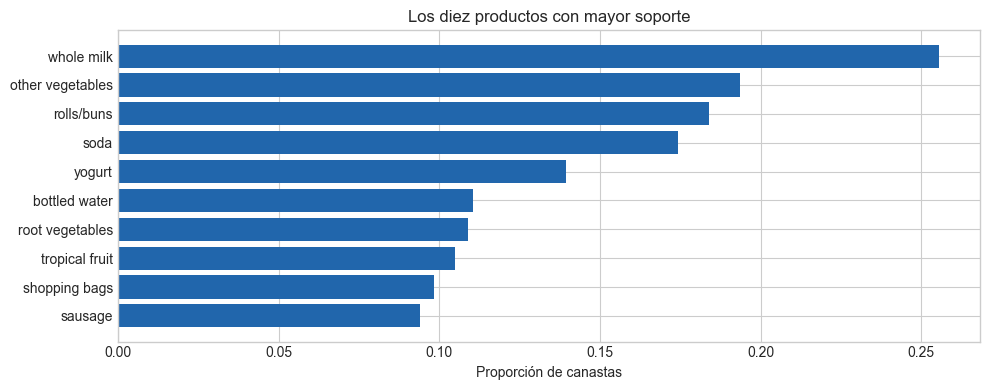

,product,basket_count,support
7,whole milk,2513,0.255516
11,other vegetables,1903,0.193493
17,rolls/buns,1809,0.183935
31,soda,1715,0.174377
4,yogurt,1372,0.139502
23,bottled water,1087,0.110524
47,root vegetables,1072,0.108998
6,tropical fruit,1032,0.104931
51,shopping bags,969,0.098526
50,sausage,924,0.093950


In [3]:
# La exploración acota el problema: productos muy raros no sostienen una predicción estable y tamaños de canasta muy distintos cambian la oportunidad de coocurrencia.

item_counts = Counter(item for basket in baskets for item in basket)
top_items = pd.DataFrame([
    {"product": item, "basket_count": count, "support": count / len(baskets)}
    for item, count in item_counts.items()
]).sort_values("basket_count", ascending=False)

figure, axis = plt.subplots(figsize=(10, 4))
axis.barh(top_items.head(10)["product"][::-1], top_items.head(10)["support"][::-1], color="#2166ac")
axis.set_title("Los diez productos con mayor soporte")
axis.set_xlabel("Proporción de canastas")
figure.tight_layout()
plt.show()

top_items.head(10)

In [4]:
# Se separan canastas retenidas antes de descubrir reglas; una regla útil debe conservar su confianza fuera de las compras con las que fue construida.

split = int(len(baskets) * 0.8)
training_baskets = baskets[:split]
evaluation_baskets = baskets[split:]

len(training_baskets), len(evaluation_baskets)

(7868, 1967)

In [5]:
# Apriori conserva candidatos frecuentes y construye pares y ternas; las ternas permiten condicionar la predicción en tropical fruit y yogurt a la vez.

def frequent_itemsets(transactions, minimum_support):
    total_transactions = len(transactions)
    single_counts = Counter(item for basket in transactions for item in basket)
    singletons = {
        frozenset([item]): count / total_transactions
        for item, count in single_counts.items()
        if count / total_transactions >= minimum_support
    }

    pair_candidates = {
        left | right
        for left, right in combinations(singletons, 2)
    }
    pair_counts = Counter(
        candidate
        for basket in transactions
        for candidate in pair_candidates
        if candidate.issubset(basket)
    )
    pairs = {
        candidate: count / total_transactions
        for candidate, count in pair_counts.items()
        if count / total_transactions >= minimum_support
    }

    triple_candidates = {
        left | right
        for left, right in combinations(pairs, 2)
        if len(left | right) == 3
    }
    triple_counts = Counter(
        candidate
        for basket in transactions
        for candidate in triple_candidates
        if candidate.issubset(basket)
    )
    triples = {
        candidate: count / total_transactions
        for candidate, count in triple_counts.items()
        if count / total_transactions >= minimum_support
    }

    return {**singletons, **pairs, **triples}

minimum_support = 0.006
itemsets = frequent_itemsets(training_baskets, minimum_support)
len(itemsets)

738

In [6]:
# La confianza estima P(consecuente | antecedente); lift evita confundir productos frecuentes con una señal condicional informativa.

rules = []
for itemset, support in itemsets.items():
    if len(itemset) < 2:
        continue
    for size in range(1, len(itemset)):
        for antecedent_items in combinations(itemset, size):
            antecedent = frozenset(antecedent_items)
            consequent = itemset - antecedent
            if antecedent not in itemsets or consequent not in itemsets:
                continue
            confidence = support / itemsets[antecedent]
            lift = confidence / itemsets[consequent]
            if confidence >= 0.25 and lift >= 1.10:
                rules.append({
                    "antecedent": " | ".join(sorted(antecedent)),
                    "consequent": " | ".join(sorted(consequent)),
                    "support": support,
                    "confidence": confidence,
                    "lift": lift,
                })

rules = pd.DataFrame(rules).sort_values(["lift", "confidence", "support"], ascending=False)
rules.head(10)

,antecedent,consequent,support,confidence,lift
137,herbs,root vegetables,0.006609,0.409449,3.728638
367,beef | whole milk,root vegetables,0.008388,0.407407,3.710048
441,beef | other vegetables,root vegetables,0.007245,0.390411,3.555270
357,other vegetables | pip fruit,tropical fruit,0.009151,0.367347,3.520445
41,berries,whipped/sour cream,0.008388,0.255814,3.512643
339,butter | whole milk,whipped/sour cream,0.006990,0.251142,3.448485
356,other vegetables | tropical fruit,pip fruit,0.009151,0.261818,3.433309
173,other vegetables | tropical fruit,root vegetables,0.012964,0.370909,3.377677
260,citrus fruit | other vegetables,root vegetables,0.010676,0.370044,3.369799
294,frozen vegetables | other vegetables,root vegetables,0.006482,0.361702,3.293834


In [7]:
# La canasta parcial se trata como condición: se recomiendan solo consecuentes de reglas cuyo antecedente es exactamente el conjunto observado.

partial_basket = frozenset({"tropical fruit", "yogurt"})
recommendations = rules.loc[
    rules["antecedent"].eq(" | ".join(sorted(partial_basket)))
].copy()
recommendations

,antecedent,consequent,support,confidence,lift
211,tropical fruit | yogurt,root vegetables,0.008643,0.303571,2.764468
355,tropical fruit | yogurt,other vegetables,0.012074,0.424107,2.202558
168,tropical fruit | yogurt,whole milk,0.015379,0.540179,2.110290
417,tropical fruit | yogurt,rolls/buns,0.008516,0.299107,1.614112


In [8]:
# La comprobación retenida mide la misma probabilidad condicional en compras no usadas por Apriori; no convierte una asociación en una intervención comercial.

def heldout_confidence(antecedent_text, consequent_text):
    antecedent = frozenset(antecedent_text.split(" | "))
    consequent = frozenset(consequent_text.split(" | "))
    eligible = [basket for basket in evaluation_baskets if antecedent.issubset(basket)]
    completed = [basket for basket in eligible if consequent.issubset(basket)]
    return len(eligible), len(completed) / len(eligible) if eligible else float("nan")

recommendations[["heldout_baskets", "heldout_confidence"]] = recommendations.apply(
    lambda row: pd.Series(heldout_confidence(row["antecedent"], row["consequent"])),
    axis=1,
)
metrics = pd.DataFrame([{
    "metric": "mean_absolute_confidence_gap",
    "value": (recommendations["confidence"] - recommendations["heldout_confidence"]).abs().mean(),
}, {
    "metric": "recommendations_with_heldout_support",
    "value": recommendations["heldout_baskets"].gt(0).sum(),
}])

recommendations, metrics

(                  antecedent        consequent   support  confidence  \
 211  tropical fruit | yogurt   root vegetables  0.008643    0.303571   
 355  tropical fruit | yogurt  other vegetables  0.012074    0.424107   
 168  tropical fruit | yogurt        whole milk  0.015379    0.540179   
 417  tropical fruit | yogurt        rolls/buns  0.008516    0.299107   
 
          lift  heldout_baskets  heldout_confidence  
 211  2.764468             64.0            0.187500  
 355  2.202558             64.0            0.406250  
 168  2.110290             64.0            0.437500  
 417  1.614112             64.0            0.296875  ,
                                  metric    value
 0          mean_absolute_confidence_gap  0.05971
 1  recommendations_with_heldout_support  4.00000)

In [9]:
# Se guardan las evidencias que permiten revisar la predicción, su soporte retenido y los límites de inferencia de reglas de asociación.

figure.savefig(submission_dir / "top_items.png", dpi=150, bbox_inches="tight")
top_items.to_csv(submission_dir / "top_items.csv", index=False)
rules.to_csv(submission_dir / "association_rules.csv", index=False)
recommendations.to_csv(submission_dir / "recommendations.csv", index=False)
metrics.to_csv(submission_dir / "model_metrics.csv", index=False)

assumptions = {
    "question": "Given a partial basket with tropical fruit and yogurt, which product is likely to complete that same basket?",
    "method": "Apriori frequent itemsets and association rules, validated on a held-out transaction segment.",
    "target": "A product co-occurring in the same purchase, not a future purchase by an identified customer.",
    "limitations": [
        "The data contain no customer identity, time stamp, price, or intervention outcome.",
        "Association and lift do not establish that a recommendation causes an additional purchase.",
        "Selecting a promotion, price, or placement is a prescriptive decision outside this activity.",
    ],
}
(submission_dir / "model_assumptions.json").write_text(
    __import__("json").dumps(assumptions, indent=2) + "\n"
)


658